# Trabajo Práctico 1 - Minería de Datos
# Año: 2025


# Carga librerías y dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import plotly.express as px
import seaborn as sns
from sklearn import decomposition
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.manifold import TSNE
from sklearn.manifold import Isomap
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
file_path= 'https://raw.githubusercontent.com/guillericci/TP1-DataMining/refs/heads/main/dxCrop_Soil.csv'
data = pd.read_csv(file_path)

# Análisis exploratorio

In [ ]:
data.shape

(8000, 9)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   temperatura         8000 non-null   float64
 1   humedad             8000 non-null   float64
 2   aguaEnSuelo         8000 non-null   float64
 3   tipoSuelo           8000 non-null   object 
 4   tipoCultivo         8000 non-null   object 
 5   nitrogeno           8000 non-null   int64  
 6   potasio             8000 non-null   int64  
 7   fosforo             8000 non-null   int64  
 8   nombreFertilizante  8000 non-null   object 
dtypes: float64(3), int64(3), object(3)
memory usage: 562.6+ KB


Podemos observar que no hay valores faltantes.

In [ ]:
data['tipoCultivo'].value_counts()

,count
tipoCultivo,
CañaAzucar,763
Maiz,753
Trigo,747
NuecesMani,732
Legumbres,728
Algodon,722
Mijo,718
Tabaco,717
SemillasOleaginosas,711


Procedemos a obtener algunos de los datos de nuestro dataset para visualizar su estructura.

In [ ]:
data.head()

,temperatura,humedad,aguaEnSuelo,tipoSuelo,tipoCultivo,nitrogeno,potasio,fosforo,nombreFertilizante
0,26.0,52.0,38.0,Arenoso,Maiz,37,0,0,Urea
1,29.0,52.0,45.0,Franco,CañaAzucar,12,0,36,DAP
2,34.0,65.0,62.0,Negro,Algodon,7,9,30,14-35-14
3,32.0,62.0,34.0,Rojo,Tabaco,22,0,20,28-28
4,28.0,54.0,46.0,Arcilloso,Arrozal,35,0,0,Urea


Ahora, visualizaremos de forma general la principales medidas descriptivas de las variables cuantitativas a considerar.

In [ ]:
data.describe()

,temperatura,humedad,aguaEnSuelo,nitrogeno,potasio,fosforo
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,30.338895,59.210731,43.580862,18.429125,3.916375,18.512500
std,4.478262,8.177366,12.596156,11.852406,5.494807,13.244113
min,20.000000,40.020000,20.000000,0.000000,0.000000,0.000000
25%,27.050000,53.277500,33.967500,9.000000,0.000000,8.000000
50%,30.240000,59.110000,42.250000,14.000000,1.000000,18.000000
75%,33.460000,65.082500,52.950000,26.000000,5.000000,30.000000
max,40.000000,80.000000,70.000000,46.000000,23.000000,46.000000


Analizamos la distribución de las variables categóricas.

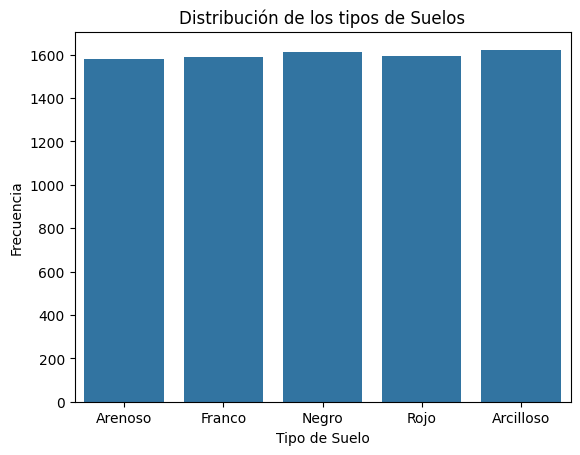

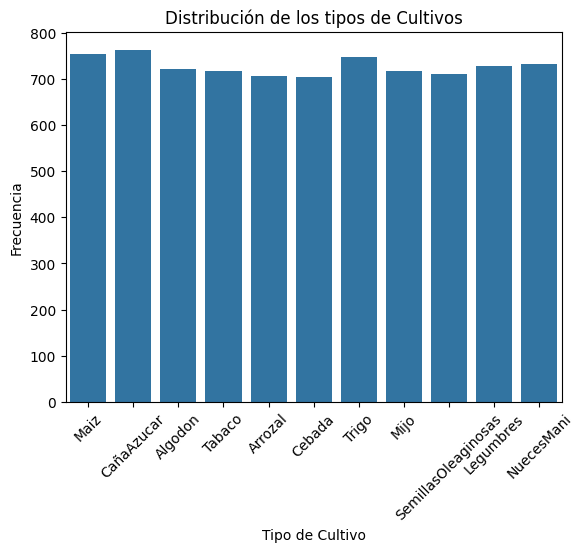

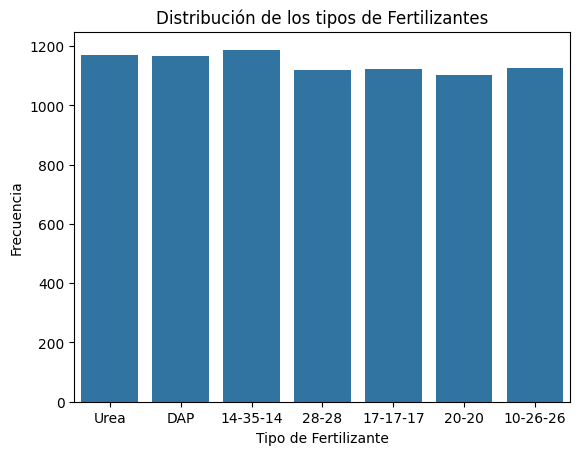

In [ ]:
sns.countplot(data=data, x='tipoSuelo')
plt.title('Distribución de los tipos de Suelos')
plt.xlabel('Tipo de Suelo')
plt.ylabel('Frecuencia')
plt.show()

sns.countplot(data=data, x='tipoCultivo')
plt.title('Distribución de los tipos de Cultivos')
plt.xlabel('Tipo de Cultivo')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.show()

sns.countplot(data=data, x='nombreFertilizante')
plt.title('Distribución de los tipos de Fertilizantes')
plt.xlabel('Tipo de Fertilizante')
plt.ylabel('Frecuencia')
plt.show()

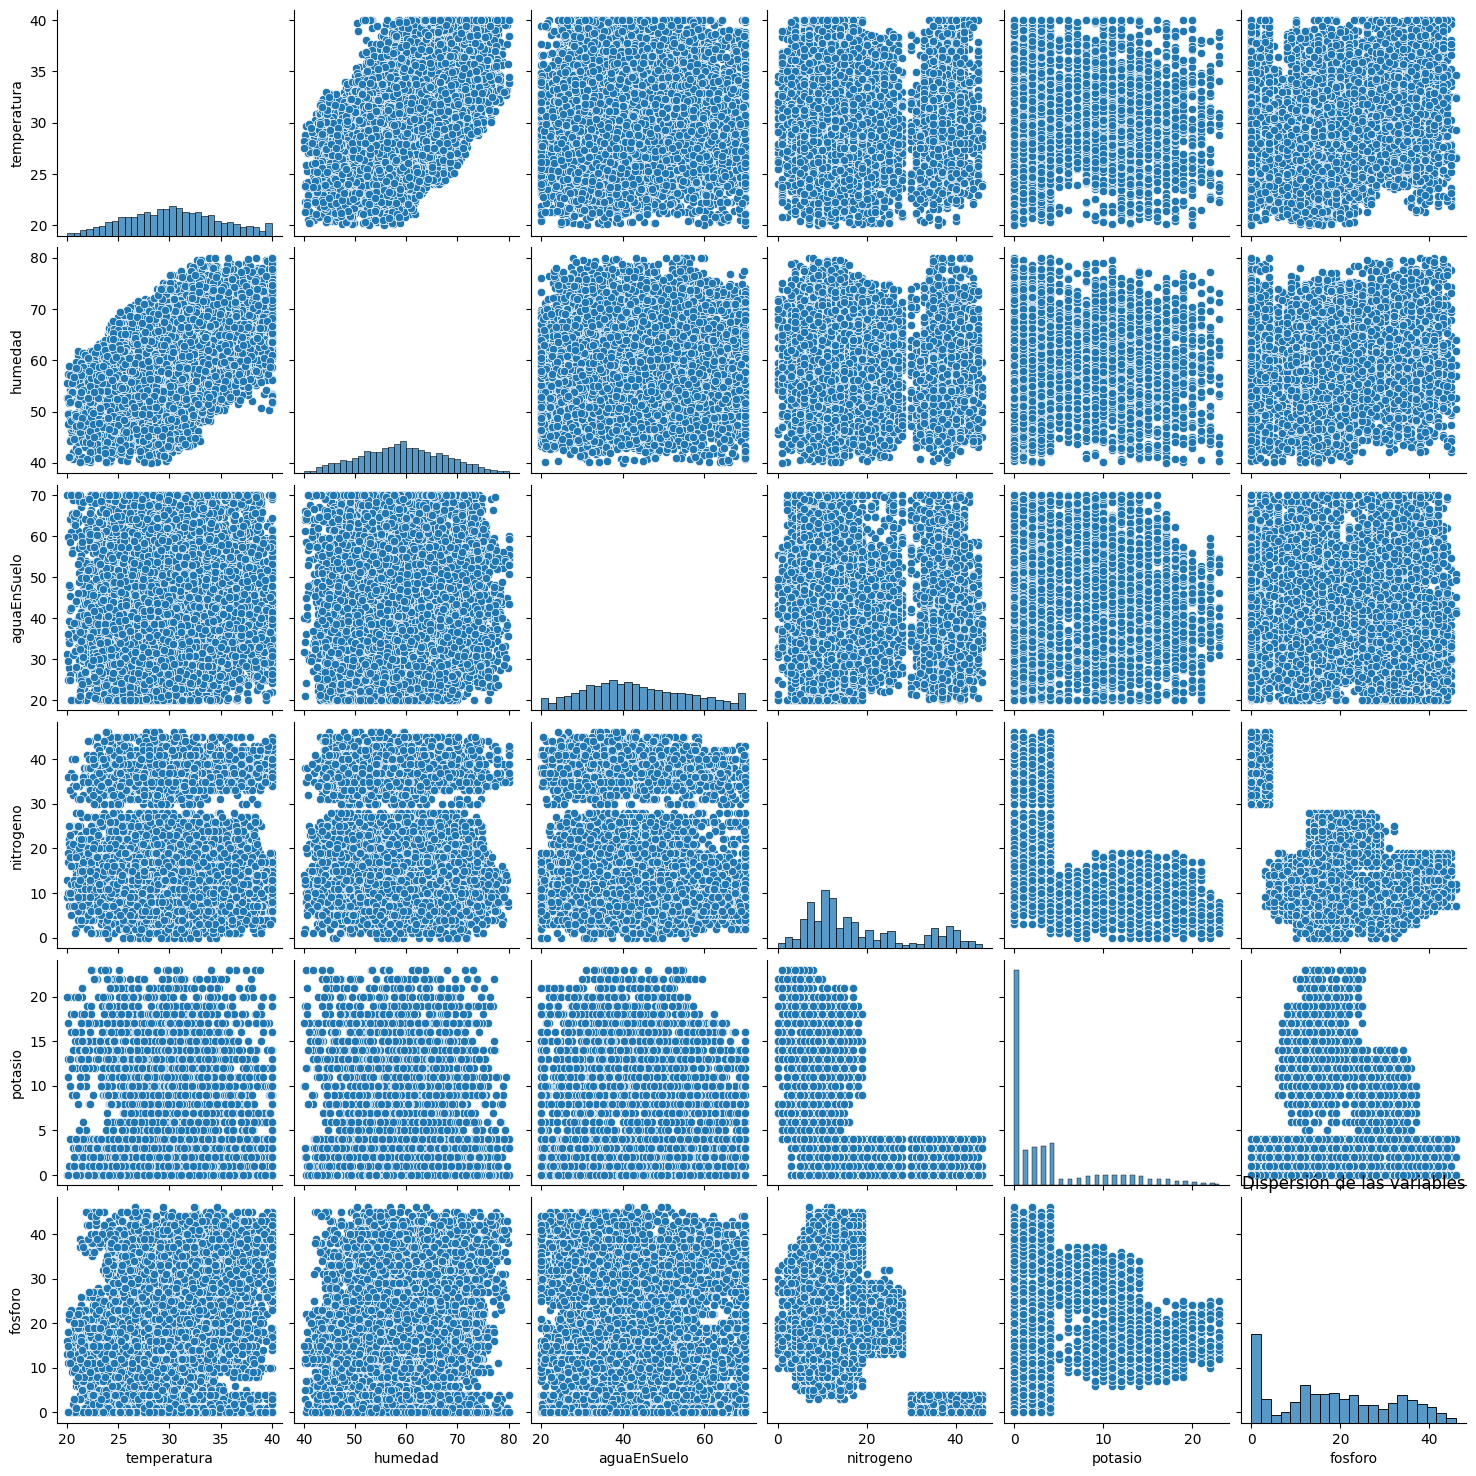

In [ ]:
sns.pairplot(data)
plt.title('Dispersión de las variables')
plt.show()

## Analisis de valores atípicos

Visualizamos la dispersión de las variables cuantitativas y si poseen valores atípicos.

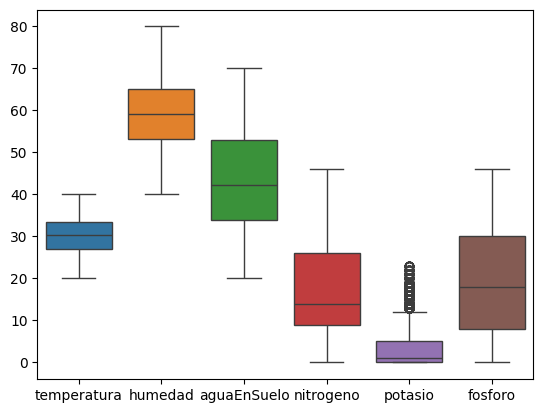

In [ ]:
cuantitativas = ['temperatura', 'humedad', 'aguaEnSuelo', 'nitrogeno', 'potasio', 'fosforo']
sns.boxplot(data=data[cuantitativas])
plt.show()

Se puede obrservar que potasio es la única variable con valores atípicos.

Analizamos su distribución.

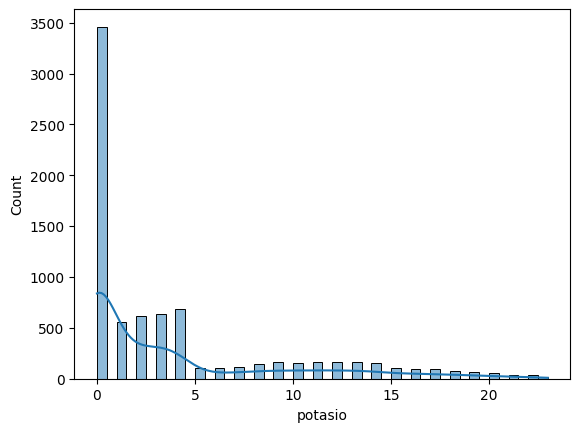

In [ ]:
sns.histplot(x = 'potasio', kde = True, data = data);
plt.show()

Analizamos la distribución de la variable potasio en relación a tipoSuelo, tipoCultivo y nombreFertilizante

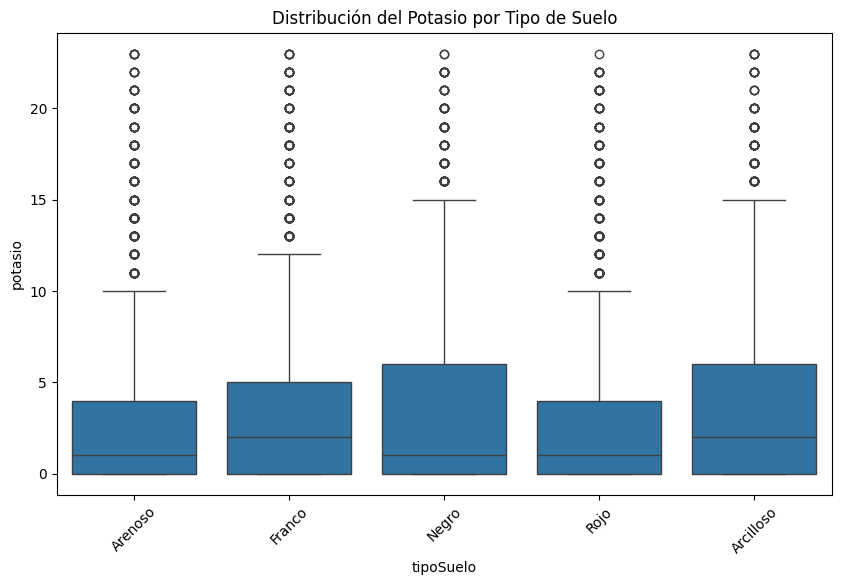

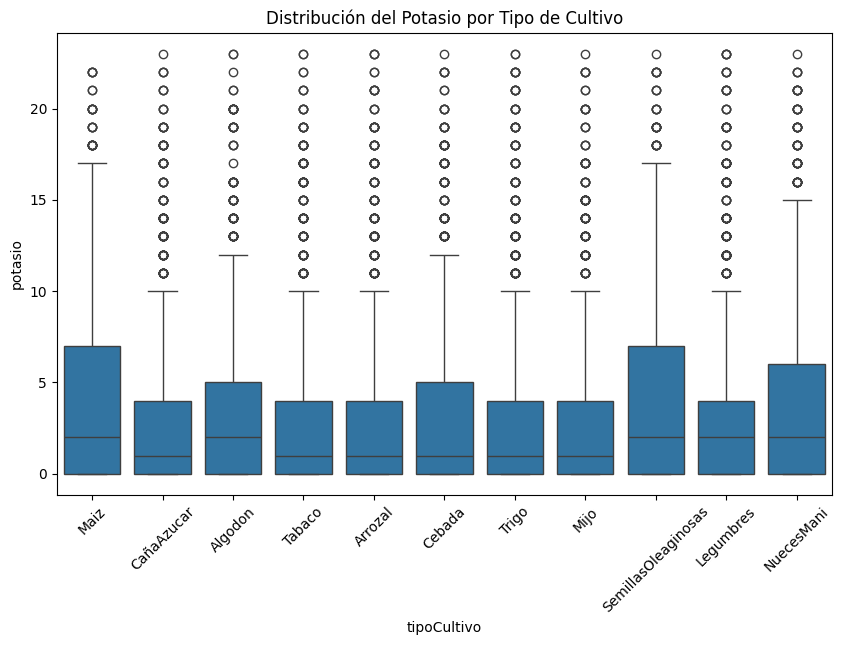

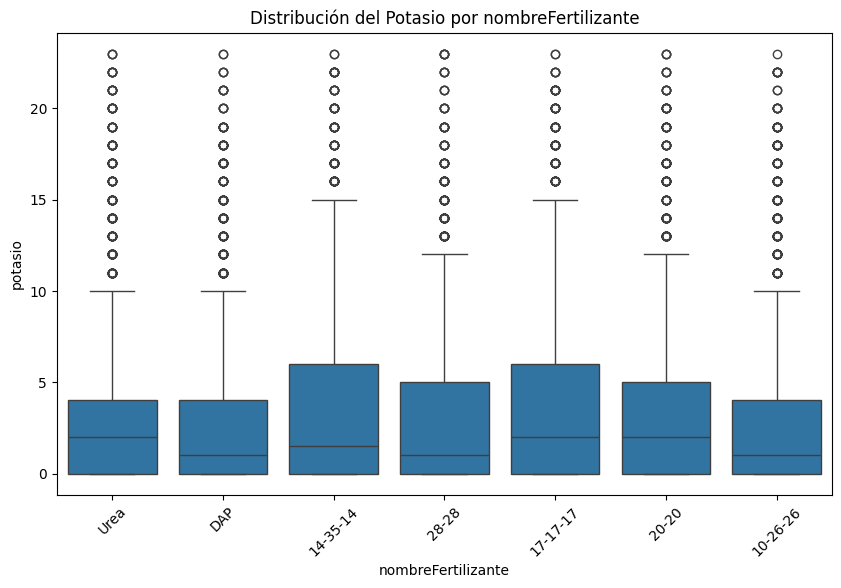

In [ ]:
# Boxplot para potasio agrupado por tipo de suelo
plt.figure(figsize=(10, 6))
sns.boxplot(x='tipoSuelo', y='potasio', data=data)
plt.title('Distribución del Potasio por Tipo de Suelo')
plt.xticks(rotation=45)  # Rotar etiquetas del eje x para mejor legibilidad
plt.show()

# Boxplot para potasio agrupado por tipo de cultivo
plt.figure(figsize=(10, 6))
sns.boxplot(x='tipoCultivo', y='potasio', data=data)
plt.title('Distribución del Potasio por Tipo de Cultivo')
plt.xticks(rotation=45)  # Rotar etiquetas del eje x para mejor legibilidad
plt.show()

# Boxplot para potasio agrupado por nombreFertilizante
plt.figure(figsize=(10, 6))
sns.boxplot(x='nombreFertilizante', y='potasio', data=data)
plt.title('Distribución del Potasio por nombreFertilizante')
plt.xticks(rotation=45)  # Rotar etiquetas del eje x para mejor legibilidad
plt.show()



Observamos que no hay relación de los valores atípicos con ninguna categoría de las variables tipoSuelo, tipoCultivo y nombreFertilizante. A su vez podemos ver que todas las categorías de las tres variables poseen valores extremos, por lo cual podemos pensar que son valores esperables de la variable 'Potasio'. En el análisis del histograma podemos ver que 'Potasio' no tiene un distribución normal. Por estas razones decidimos conservar los valores extremos entendiendo que son propios del comportamiento del 'Potasio'.

##Correlación

Gráfico de la matriz de correlación entre las variables numéricas del dataset.
Este gráfico muestra la relación lineal entre las variables, con valores cercanos a 1 o -1 indicando alta correlación positiva o negativa, respectivamente.

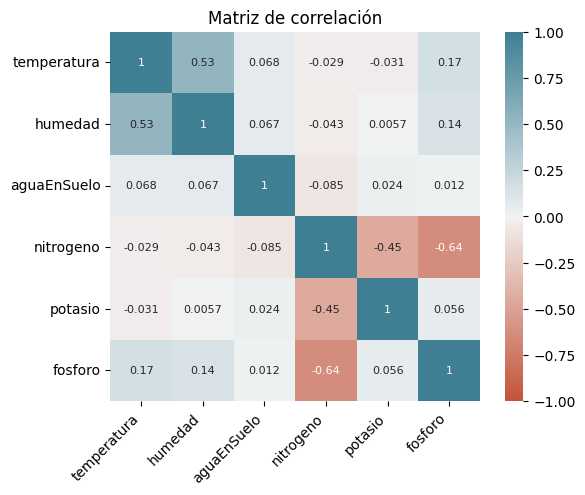

In [ ]:
data_num = data.drop(["tipoSuelo","tipoCultivo","nombreFertilizante"], axis=1).corr()
ax = sns.heatmap(
    data_num,
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True,
    annot = True,
    annot_kws = {'size': 8}
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    horizontalalignment='right'
)
plt.title('Matriz de correlación')
plt.show()

Observamos que la mayoría de las variables presentan baja correlación entre sí, lo cual es deseable cuando se busca que las variables sean independientes (correlación cercana a 0).

La correlación más destacada se encuentra entre fósforo y nitrógeno. A pesar de esta correlación, decidimos mantener ambas variables en el análisis, ya que pueden aportar información valiosa al aplicar técnicas de reducción de dimensionalidad.

#Codificación y estandarización

Por medio de un preprocesador estadarizamos las variables númericas con StandarScaler y codificamos con OneHotEncoder las variables categóricas.

In [ ]:
#Guardamos las etiquetas de la variable target
y=data['tipoCultivo']

# Define varbles categoricas y numericas
categorical_features = ['tipoSuelo', 'nombreFertilizante']
numerical_features = ['temperatura', 'humedad', 'aguaEnSuelo', 'nitrogeno', 'potasio', 'fosforo']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first'), categorical_features)],
    remainder='drop' # Drop 'tipoCultivo'
)

# Fit y transform las columnas excepto tipoCultivo
data_processed = preprocessor.fit_transform(data.drop(columns=['tipoCultivo']))

# nombre de features
feature_names = numerical_features + list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features))

# Convierte de vuelta en dataframe
data_processed = pd.DataFrame(data_processed, columns=feature_names)

data_processed.head()

,temperatura,humedad,aguaEnSuelo,nitrogeno,potasio,fosforo,tipoSuelo_Arenoso,tipoSuelo_Franco,tipoSuelo_Negro,tipoSuelo_Rojo,nombreFertilizante_14-35-14,nombreFertilizante_17-17-17,nombreFertilizante_20-20,nombreFertilizante_28-28,nombreFertilizante_DAP,nombreFertilizante_Urea
0,-0.968940,-0.881847,-0.443088,1.566942,-0.712786,-1.397878,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-0.298995,-0.881847,0.112671,-0.542466,-0.712786,1.320481,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.817579,0.708007,1.462374,-0.964348,0.925227,0.867421,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0.370949,0.341118,-0.760666,0.301297,-0.712786,0.112321,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,-0.522310,-0.637254,0.192066,1.398190,-0.712786,-1.397878,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


#Técnicas de Reducción de Dimensionalidad

Procederemos a realizar distintas técnicas de reducción de dimensionalidad con el objetivo de visualizar los datos y entender su comportamiento y deslucidar si los mismos presentan agrupamientos latentes.

In [ ]:
X = data_processed

## PCA

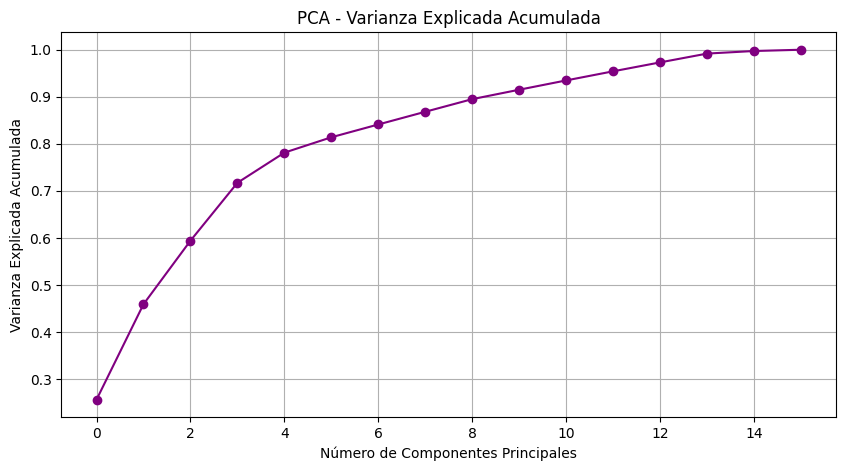

In [ ]:
# Aplicamos PCA
pca = PCA()
X_pca = pca.fit_transform(X)  # Transformamos X en componentes principales

plt.figure(figsize=(10,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', color='purple')
plt.xlabel('Número de Componentes Principales')  # Eje X: número de componentes
plt.ylabel('Varianza Explicada Acumulada')       # Eje Y: % de varianza explicada
plt.title('PCA - Varianza Explicada Acumulada')
plt.grid(True)
plt.show()

En el gráfico 'Varianza Explicada Acumulada' podemos ver que 4 componenetes principales explican más del 90% de la varianza. A su vez 2 componentes explican más del 70%, por lo que un gráfico de dos dimensiones es representativo de los datos.

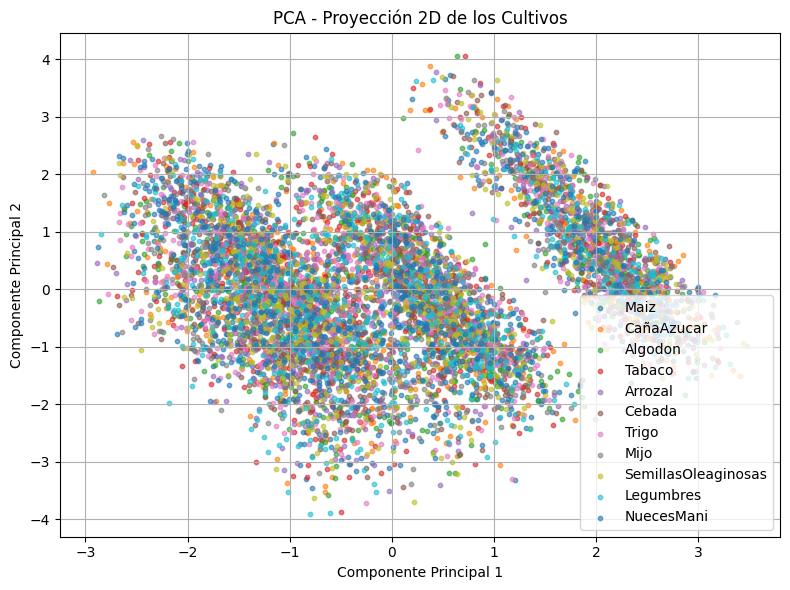

In [ ]:
# Reducir a 2 componentes para visualizar
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X)  # Volvemos a aplicar PCA, ahora pidiendo solo 2 componentes

# Graficamos componentes principales con clases
plt.figure(figsize=(8,6))
for clase in y.unique():  # Para cada tipo de cultivo...
    plt.scatter(
        X_pca_2[y == clase, 0],  # Componente 1
        X_pca_2[y == clase, 1],  # Componente 2
        label=clase, # Nombre de la clase
        alpha=0.6, #permite ver superposición
        s=10,#reduce el tamaño de los puntos
      )
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('PCA - Proyección 2D de los Cultivos')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

También procederemos a graficar los datos en 3D, entendiendo que 3 componentes principales explican casi el 80% de la varianza

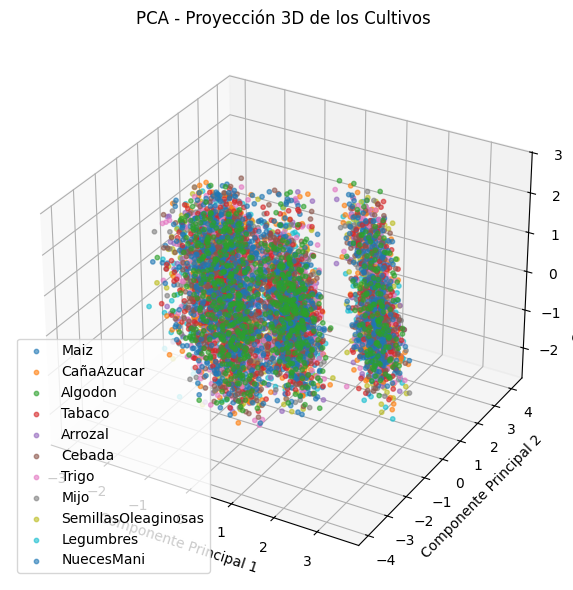

In [ ]:
# Reducimos a 3 componentes para visualizar
pca_2 = PCA(n_components=3)
X_pca_2 = pca_2.fit_transform(X)  # Volvemos a aplicar PCA, con 3 componentes

# Crear la figura 3D
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')  # projection='3d' es clave

# Graficar componentes principales con clases
for clase in y.unique():
    ax.scatter(
        X_pca_2[y == clase, 0],  # Componente 1
        X_pca_2[y == clase, 1],  # Componente 2
        X_pca_2[y == clase, 2],  # Componente 3
        label=clase,
        alpha=0.6,
        s=10,
    )

ax.set_xlabel('Componente Principal 1')
ax.set_ylabel('Componente Principal 2')
ax.set_zlabel('Componente Principal 3')
ax.set_title('PCA - Proyección 3D de los Cultivos')
ax.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

En ambas gráficas realizadas con PCA podemos visualizar con claridad 3 agrupamientos de datos.

### Contribuciones de cada variable

                                  PC1       PC2       PC3       PC4       PC5  \
temperatura                 -0.305186  0.616287 -0.046767  0.128003  0.708344   
humedad                     -0.307481  0.602099 -0.017089  0.226822 -0.700464   
aguaEnSuelo                 -0.120973  0.087448  0.932236 -0.322238 -0.000629   
nitrogeno                    0.607400  0.343305  0.019290  0.070875  0.031936   
potasio                     -0.335080 -0.347963  0.224367  0.757635  0.077932   
fosforo                     -0.562425 -0.104363 -0.278449 -0.499085 -0.013440   
tipoSuelo_Arenoso            0.001624  0.004449  0.005645 -0.007416 -0.001758   
tipoSuelo_Franco            -0.000195 -0.000518 -0.005339  0.005816  0.001247   
tipoSuelo_Negro             -0.004055 -0.004809 -0.002589  0.002068 -0.004167   
tipoSuelo_Rojo               0.000067  0.003166 -0.005560 -0.004389  0.005196   
nombreFertilizante_14-35-14  0.000669 -0.003376  0.007220  0.001713  0.001078   
nombreFertilizante_17-17-17 

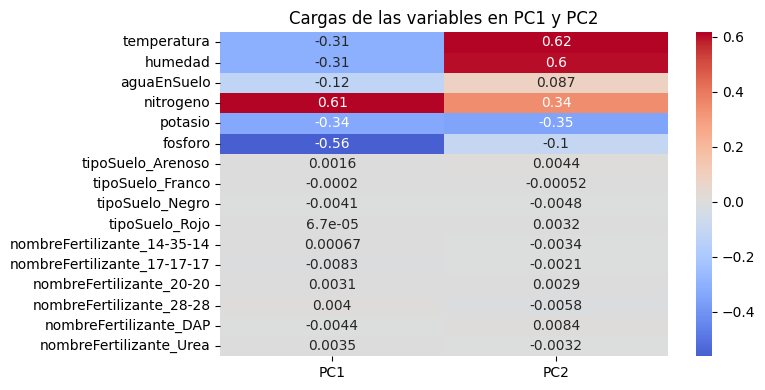

In [ ]:
# Cargas de los componentes
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=X.columns )

print(loadings)

# Gráfico de contribuciones a las dos primeras componentes
plt.figure(figsize=(8, 4))
sns.heatmap(loadings.iloc[:, :2], annot=True, cmap="coolwarm", center=0)
plt.title("Cargas de las variables en PC1 y PC2")
plt.tight_layout()
plt.show()

## ISOMAP

Isomap con 5 vecinos...


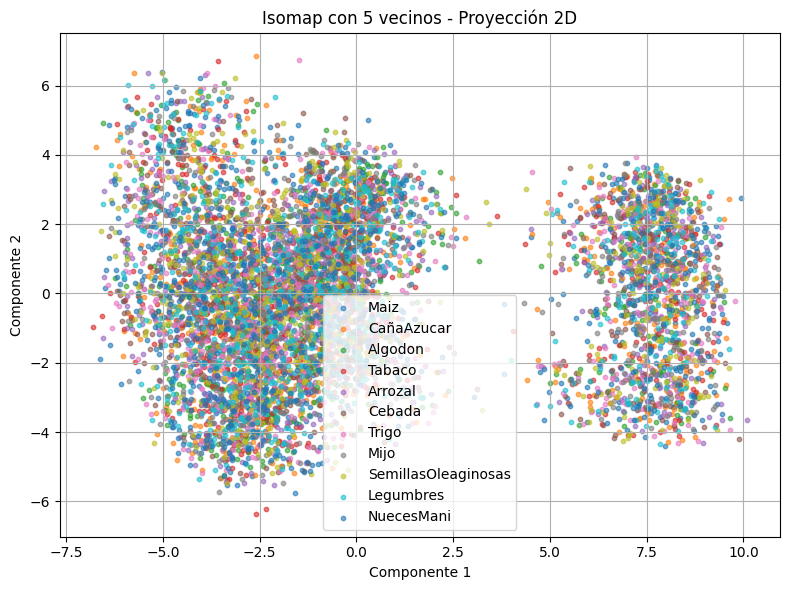

Isomap con 10 vecinos...


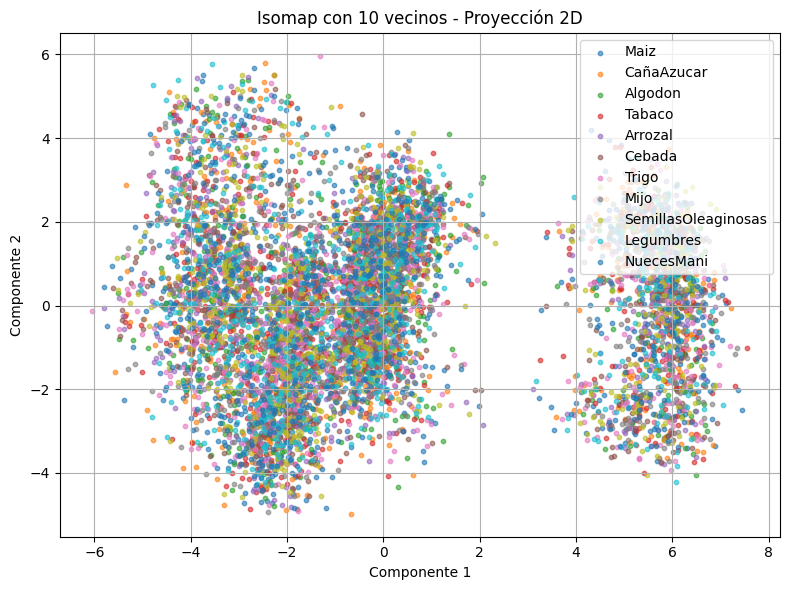

Isomap con 15 vecinos...


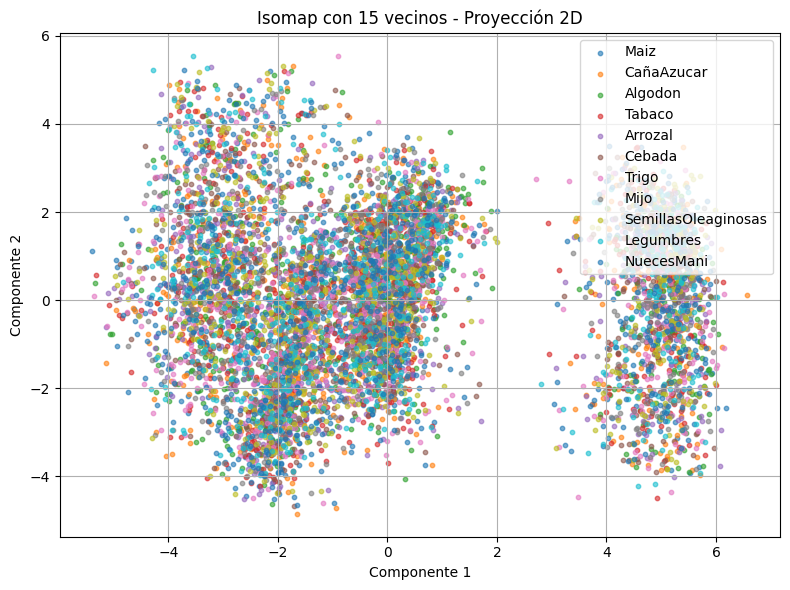

In [ ]:
# Vamos a probar con distintos valores de vecinos (k)
vecinos = [5, 10, 15]

for n in vecinos:
    print(f"Isomap con {n} vecinos...")

    #Aplicamos Isomap con 2 componentes
    isomap = Isomap(n_neighbors=n, n_components=2)
    X_iso = isomap.fit_transform(X)

    #raficar los resultados
    plt.figure(figsize=(8,6))
    for clase in y.unique():  # Para cada tipo de cultivo
        plt.scatter(
            X_iso[y == clase, 0],
            X_iso[y == clase, 1],
            label=clase,
            alpha=0.6,
            s=10
        )
    plt.xlabel('Componente 1')
    plt.ylabel('Componente 2')
    plt.title(f'Isomap con {n} vecinos - Proyección 2D')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Podemos ver dos agrupamientos marcados y el número de vecinos 15 permite visualizarlo mejor. Procederemos a gráficar los datos con 3 componentes y número de vecinos igual a 20.

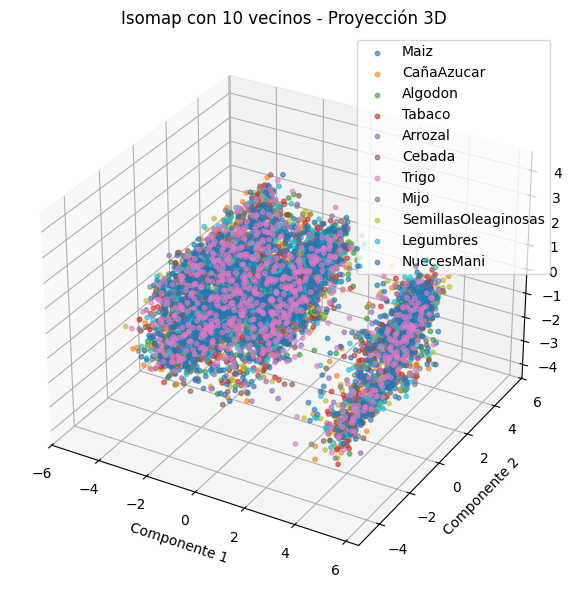

In [ ]:

#Aplicar Isomap con 3 componentes y n_neighbors 20

isomap = Isomap(n_neighbors=20, n_components=3)
X_iso = isomap.fit_transform(X)

# Crear la figura 3D
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Graficar los resultados
for clase in y.unique():
    ax.scatter(
        X_iso[y == clase, 0],
        X_iso[y == clase, 1],
        X_iso[y == clase, 2],  # Agregar la tercera componente
        label=clase,
        alpha=0.6,
        s=10
    )

ax.set_xlabel('Componente 1')
ax.set_ylabel('Componente 2')
ax.set_zlabel('Componente 3')  # Agregar etiqueta para el eje z
ax.set_title(f'Isomap con 10 vecinos - Proyección 3D')
ax.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Podemos ver dos agrupamientos de datos bien marcados.

## t-SNE

Procederemos a realizar T-sne con número de perplejidades igual a 5, 10 y 50, con dos componantes principales y 500 iteraciones

t-SNE con perplejidad=[5, 30, 50]


/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


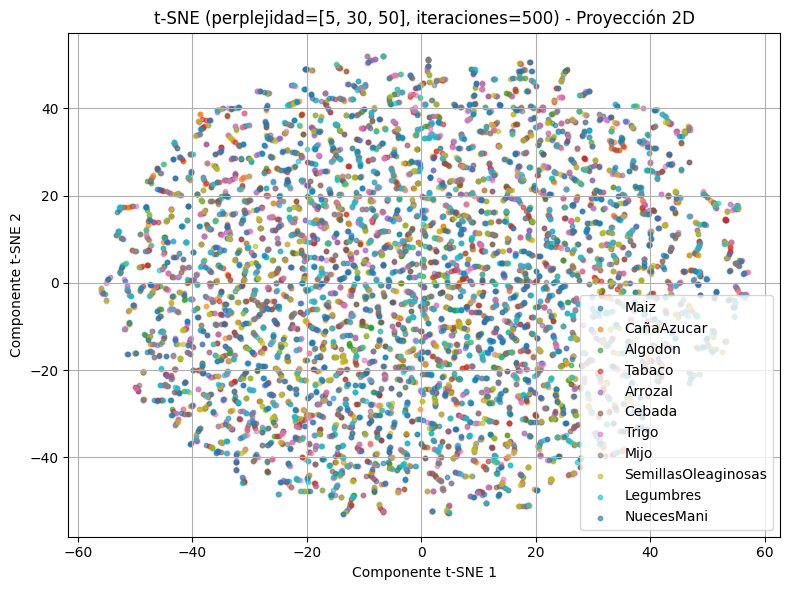

t-SNE con perplejidad=[5, 30, 50]


/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


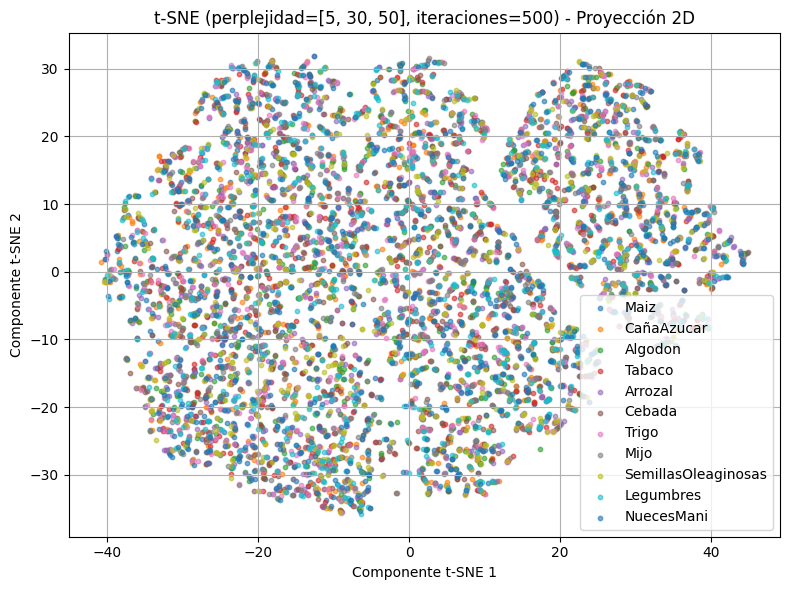

t-SNE con perplejidad=[5, 30, 50]


/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


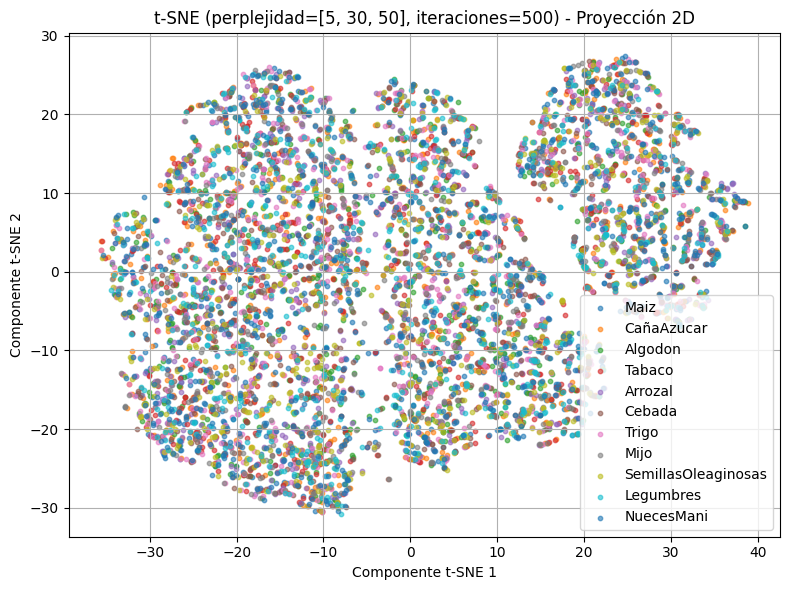

In [ ]:
# Elegimos algunas configuraciones para probar t-SNE
perplejidades = [5, 30, 50]       # afecta cómo t-SNE balancea lo local vs global
iteraciones = 500                 # cantidad de pasos de optimización
componentes = 2                   # para visualizar en 2D

for perp in perplejidades:
    print(f"t-SNE con perplejidad={perplejidades}")

    # Configuracion tsne
    tsne = TSNE(n_components=componentes, perplexity=perp, n_iter=iteraciones, random_state=0)
    X_tsne = tsne.fit_transform(X)

    # Grafica
    plt.figure(figsize=(8,6))
    for clase in y.unique():  # Para cada tipo de cultivo
        plt.scatter(
            X_tsne[y == clase, 0],
            X_tsne[y == clase, 1],
            label=clase,
            alpha=0.6,
            s=10
        )
    plt.xlabel('Componente t-SNE 1')
    plt.ylabel('Componente t-SNE 2')
    plt.title(f't-SNE (perplejidad={perplejidades}, iteraciones={iteraciones}) - Proyección 2D')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Podemos visualizar mejor los agrupamientos con el número de perplejidades igual a 50. Ahora graficaremos los datos con ese número de perplejidades pero variando las iteraciones a 1000.

t-SNE con perplejidad=50


/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


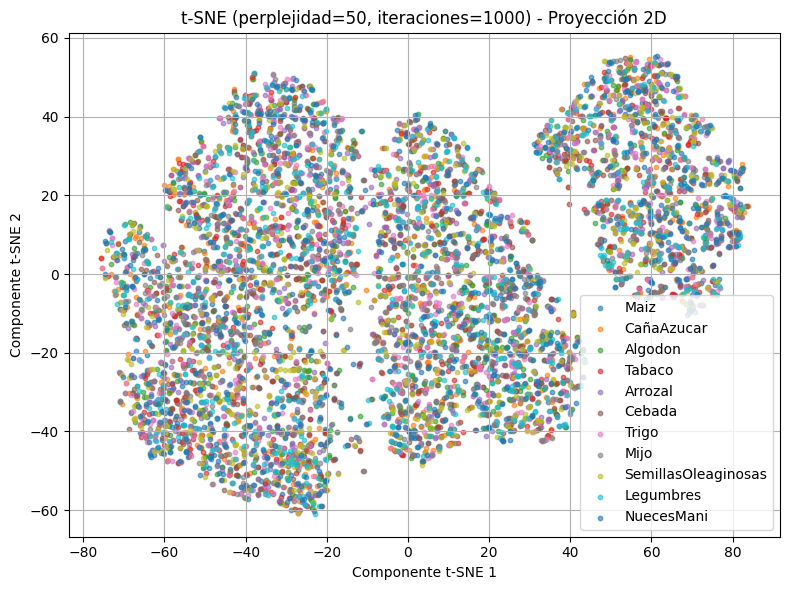

In [ ]:
# Elegimos algunas configuraciones para probar t-SNE
perplejidades = 50       # afecta cómo t-SNE balancea lo local vs global
iteraciones = 1000               # cantidad de pasos de optimización
componentes = 2                   # para visualizar en 2D


print(f"t-SNE con perplejidad={perplejidades}")

# Configuracion tsne
tsne = TSNE(n_components=componentes, perplexity=perp, n_iter=iteraciones, random_state=0)
X_tsne = tsne.fit_transform(X)

# Grafica
plt.figure(figsize=(8,6))
for clase in y.unique():  # Para cada tipo de cultivo
    plt.scatter(
        X_tsne[y == clase, 0],
        X_tsne[y == clase, 1],
        label=clase,
        alpha=0.6,
        s=10
    )
plt.xlabel('Componente t-SNE 1')
plt.ylabel('Componente t-SNE 2')
plt.title(f't-SNE (perplejidad={perplejidades}, iteraciones={iteraciones}) - Proyección 2D')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Ahora modificaremos el número de componentes principales a 3 y graficaremos en 3D. El número de perplejidad lo mantendremos en 50 y las iteraciones en 500.

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


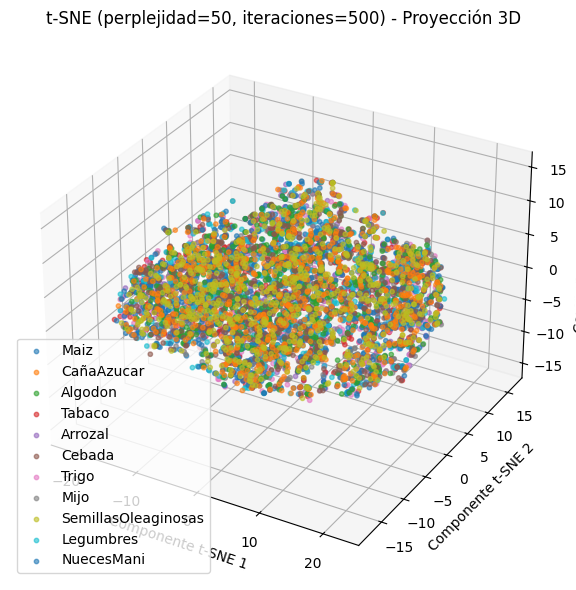

In [ ]:
# Elegimos algunas configuraciones para probar t-SNE
perplejidad = 50      # afecta cómo t-SNE balancea lo local vs global
iteraciones = 500                 # cantidad de pasos de optimización
componentes = 3                   # para visualizar en 3D

# Configuracion tsne
tsne = TSNE(n_components=componentes, perplexity=perplejidad, n_iter=iteraciones, random_state=0)
X_tsne = tsne.fit_transform(X)

# Grafica 3D
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

for clase in y.unique():  # Para cada tipo de cultivo
    ax.scatter(
        X_tsne[y == clase, 0],
        X_tsne[y == clase, 1],
        X_tsne[y == clase, 2],  # Tercera componente
        label=clase,
        alpha=0.6,
        s=10
    )

ax.set_xlabel('Componente t-SNE 1')
ax.set_ylabel('Componente t-SNE 2')
ax.set_zlabel('Componente t-SNE 3')  # Etiqueta para el eje z
ax.set_title(f't-SNE (perplejidad={perplejidad}, iteraciones={iteraciones}) - Proyección 3D') # Corregido: perp -> perplejidad
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Podemos ver como el gráfico en 3D es menos informativo y empeora la interpretacion y visualización de los datos.

# PCA con filtrado de Maíz, Cebada y Trigo

Realizamos la técnica de Análisis de Componentes Principales (PCA) con 3 componentes principales sobre el subconjunto de los datos considerando solamente estos tipos de
cultivos: Maíz, Cebada, Trigo.


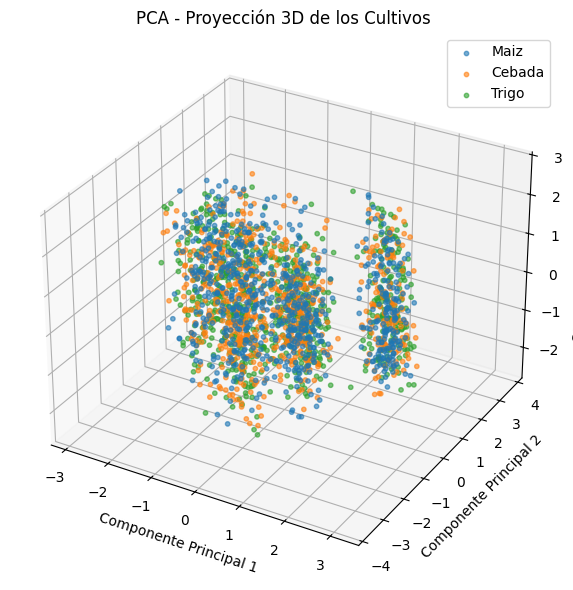

In [ ]:
# Filtrar los datos
cultivos_filtrados = ['Maiz', 'Cebada', 'Trigo']
mask = y.isin(cultivos_filtrados)
X_sub = X[mask].copy()
y_sub = y[mask]

# Reaplicar PCA para este subconjunto
pca_sub = PCA(n_components=3)
X_sub_pca = pca_sub.fit_transform(X_sub)


# Crear la figura 3D
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')  # projection='3d' es clave

# Graficar componentes principales con clases
for clase in y_sub.unique():
    ax.scatter(
        X_sub_pca[y_sub == clase, 0],  # Componente 1
        X_sub_pca[y_sub == clase, 1],  # Componente 2
        X_sub_pca[y_sub == clase, 2],  # Componente 3
        label=clase,
        alpha=0.6,
        s=10,
    )

ax.set_xlabel('Componente Principal 1')
ax.set_ylabel('Componente Principal 2')
ax.set_zlabel('Componente Principal 3')
ax.set_title('PCA - Proyección 3D de los Cultivos')
ax.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Podemos visualizar 3 agrupamientos de datos, similares a los graficados con PCA antes de realizar el filtrado.

#Clustering

Procederemos a realizar técnicas de clustering que nos permitan dividir los datos en clusters. Utilizaremos K-Means y Clustering Jerarquico.

##  K-Means

Utilizaremos el método del codo y de GAP para determinar el número de clusters.

###GAP Statistic

In [ ]:
def calculate_intra_cluster_dispersion(X_gap, k):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X_gap)
    return kmeans.inertia_

In [ ]:
gaps = []
max_k = 10
for k in range(1, max_k + 1):
    # Calculo la inercia real sobre mis datos reales
    real_inertia = calculate_intra_cluster_dispersion(X_sub, k)
    #Calculo al inercia de datos aleatorios con la mismsa estrucutra que mis datos originales
    inertia_list = []
    for _ in range(10):
      random_data = np.random.rand(*X_sub.shape)
      intra_cluster_dispersion = calculate_intra_cluster_dispersion(random_data, k)
      inertia_list.append(intra_cluster_dispersion)

    reference_inertia = np.mean(inertia_list)

    #Aplico la funcion de gap
    gap = np.log(reference_inertia) - np.log(real_inertia)
    gaps.append(gap)

optimal_k = np.argmax(gaps) + 1

In [ ]:
print("Valor óptimo de cantidad de clusters:",optimal_k)

Valor óptimo de cantidad de clusters: 10


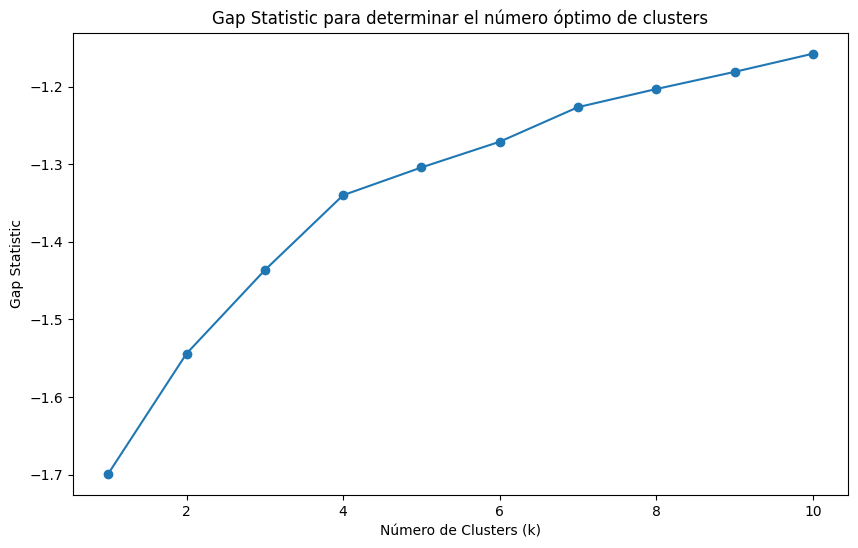

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, max_k + 1), gaps, marker='o')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Gap Statistic')
plt.title('Gap Statistic para determinar el número óptimo de clusters')
plt.show()

Por el método de GAP determinamos que el valor óptimo de clusters es 10.

###Método del codo

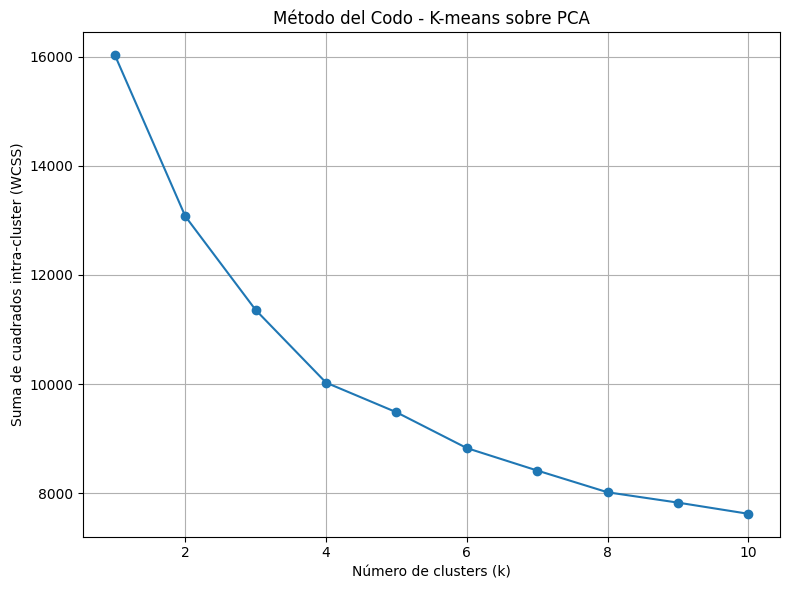

In [ ]:
wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_sub)
    wcss.append(kmeans.inertia_)  # inertia_ es el WCSS

# Graficar el codo
plt.figure(figsize=(8,6))
plt.plot(K_range, wcss, marker='o')
plt.title('Método del Codo - K-means sobre PCA')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Suma de cuadrados intra-cluster (WCSS)')
plt.grid(True)
plt.tight_layout()
plt.show()


Del análisis visual del gráfico del método del codo, observamos un cambio en la pendiente alrededor de los valores 4 y 6, lo que sugiere que podrían ser valores adecuados para el número de clusters. Nos vamos a quedar con 4.

Como ambas métodos dieron valores diferentes utilizaremos el Coeficiente de Silhouette para definir.

###Coeficiente de Silhouette

In [ ]:
def calculate_silhouette(X_silhouette, k):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X_silhouette)
    labels = kmeans.labels_
    silhouette_avg = silhouette_score(X_silhouette, labels)
    sample_silhouette_values = silhouette_samples(X_silhouette, labels)
    return silhouette_avg, sample_silhouette_values

In [ ]:
max_k = 10

silhouette_scores = []
for k in range(2, max_k + 1):
    silhouette_avg, _ = calculate_silhouette(X_sub, k)
    silhouette_scores.append(silhouette_avg)

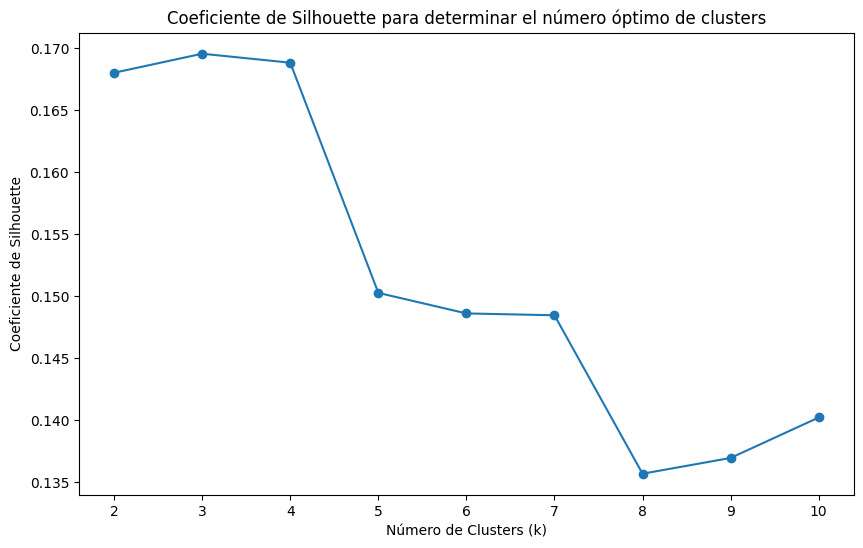

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(2, max_k + 1), silhouette_scores, marker='o')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Coeficiente de Silhouette')
plt.title('Coeficiente de Silhouette para determinar el número óptimo de clusters')
plt.show()

Por el método del coeficiente de Silhouette, el valor óptimo de clusters es 3.

###Análisis visual de K-means con diferentes números de clusters

Realizaremos una comparación mediante gráficos de los agrupamientos resultantes al variar el número de clusters resultantes de los métodos para determinar el número de clusters óptima: 3,4 y 6.

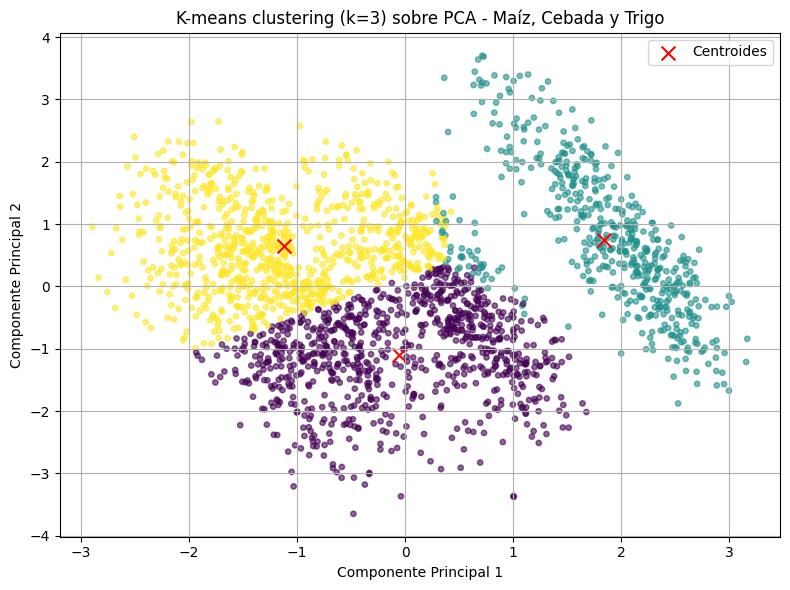

In [ ]:
# Aplicar K-means con 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
#entrenamos el modelo
clusters = kmeans.fit_predict(X_sub_pca)

# Graficar los clusters asignados
plt.figure(figsize=(8,6))
plt.scatter(
    X_sub_pca[:, 0],
    X_sub_pca[:, 1],
    c=clusters,
    cmap='viridis',
    alpha=0.6,
    s=15
)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c='red', marker='x', s=100, label='Centroides')
plt.title('K-means clustering (k=3) sobre PCA - Maíz, Cebada y Trigo')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

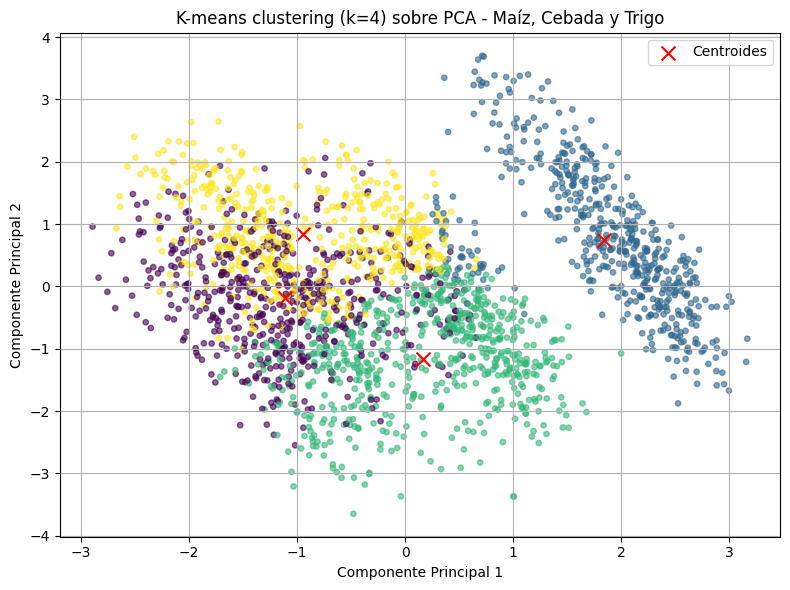

In [ ]:
# Aplicar K-means con 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_sub_pca)

# Graficar los clusters asignados
plt.figure(figsize=(8,6))
plt.scatter(
    X_sub_pca[:, 0],
    X_sub_pca[:, 1],
    c=clusters,
    cmap='viridis',
    alpha=0.6,
    s=15
)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c='red', marker='x', s=100, label='Centroides')
plt.title('K-means clustering (k=4) sobre PCA - Maíz, Cebada y Trigo')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

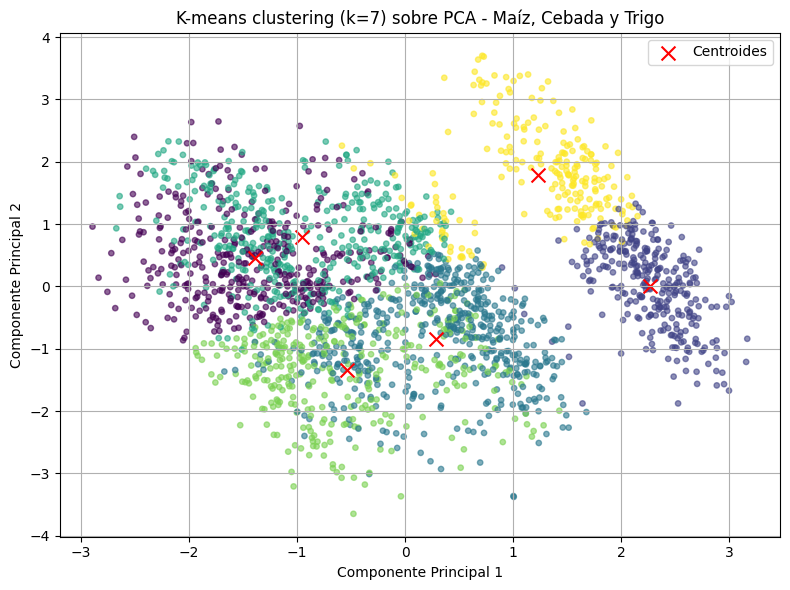

In [ ]:
# Aplicar K-means con 6 clusters
kmeans = KMeans(n_clusters=6, random_state=42)
clusters = kmeans.fit_predict(X_sub_pca)

# Graficar los clusters asignados
plt.figure(figsize=(8,6))
plt.scatter(
    X_sub_pca[:, 0],
    X_sub_pca[:, 1],
    c=clusters,
    cmap='viridis',
    alpha=0.6,
    s=15
)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c='red', marker='x', s=100, label='Centroides')
plt.title('K-means clustering (k=7) sobre PCA - Maíz, Cebada y Trigo')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Analizando los 3 gráficos parece ser k=3 el que mejor agrupamiento genera.

###Relación entre Temperatura, Potasio y Agua en Suelo, por clusters (gráfico 3D)

Asignaremos un cluster a cada registro estableciendo el número de clusters en 3.
Luego realizaremos un gráfico 3d utilizando 3 atributos: temperatura, potasio y aguaEnSuelo. La elección de las mismas se debe a su baja correlación como puede observarse en el correlograma.

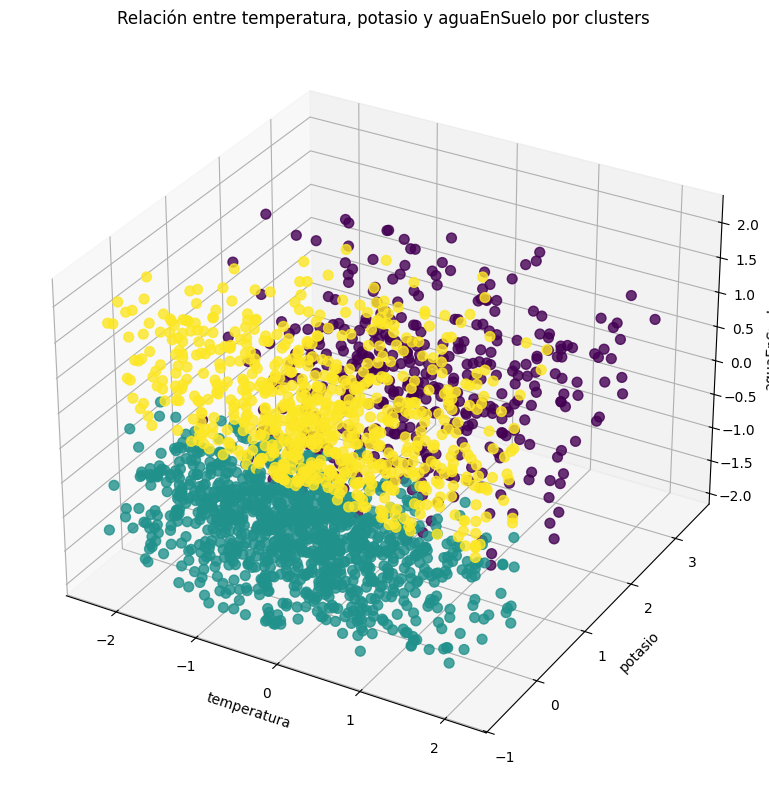

In [ ]:
# Selección de atributos
atributos = ['temperatura', 'potasio', 'aguaEnSuelo']
X_3d = X_sub[atributos]

# K-means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_3d)

# Asignar los clusters al DataFrame
X_sub['Cluster KMeans'] = clusters

# Gráfico 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_3d['temperatura'],  # Componente principal 1
    X_3d['potasio'],  # Componente principal 2
    X_3d['aguaEnSuelo'],  # Componente principal 3
    c=clusters,  # clusters calculados con X_sub_pca si es necesario
    cmap='viridis',
    s=50,
    alpha=0.8
)

ax.set_xlabel('temperatura')  # Etiqueta del eje x
ax.set_ylabel('potasio')  # Etiqueta del eje y
ax.set_zlabel('aguaEnSuelo')  # Etiqueta del eje z
ax.set_title('Relación entre temperatura, potasio y aguaEnSuelo por clusters')  # Título del gráfico
plt.tight_layout()
plt.show()


Podemos visualizar un buen agrupamiento de los datos en función de estas 3 variables.

## Clustering Jerárquico sobre el PCA filtrado

Utilizaremos las métricas del Coeficiente de Silhouette y de GAP para respaldar el dendograma y determinar el número de clusters en donde realizar el corte.

## Coeficiente de Silhouette

In [ ]:
def calculate_silhouette(X_scaled, k, linkage='ward'):
    clustering = AgglomerativeClustering(n_clusters=k, linkage=linkage)
    labels = clustering.fit_predict(X_scaled)
    silhouette_avg = silhouette_score(X_scaled, labels)
    sample_silhouette_values = silhouette_samples(X_scaled, labels)
    return silhouette_avg, sample_silhouette_values



In [ ]:
max_k = 10
K_range = range(2, max_k + 1)
silhouette_scores = []
for k in K_range:
    silhouette_avg, _ = calculate_silhouette(X_sub, k)
    silhouette_scores.append(silhouette_avg)

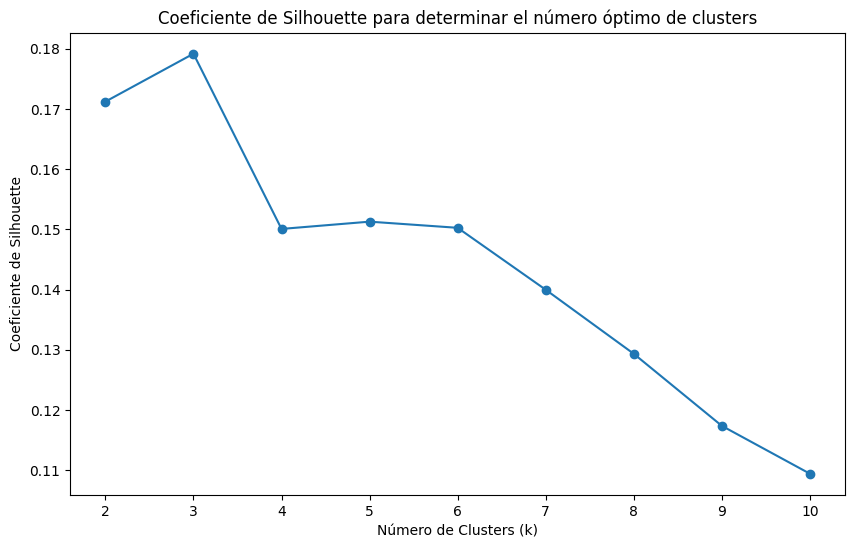

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(2, max_k + 1), silhouette_scores, marker='o')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Coeficiente de Silhouette')
plt.title('Coeficiente de Silhouette para determinar el número óptimo de clusters')
plt.show()

In [ ]:
optimal_k_silhouette = K_range[silhouette_scores.index(max(silhouette_scores))]
print("K óptimo según Silhouette:", optimal_k_silhouette)

K óptimo según Silhouette: 3


## GAP

In [ ]:
def calculate_intra_cluster_dispersion(X_scaled, k, linkage='ward'):
    clustering = AgglomerativeClustering(n_clusters=k, linkage=linkage)
    labels = clustering.fit_predict(X_scaled)

    # Calcula los centroides de los clústeres como la media de los puntos dentro de cada clúster
    centroids = np.array([np.mean(X_scaled[labels == i], axis=0) for i in range(k)])

    # Calcula la dispersión intraclúster sumando las distancias al cuadrado entre los puntos y sus centroides
    # np.linalg.norm calcula la norma (distancia euclidiana) entre los puntos y el centroide correspondiente
    intra_cluster_dispersion = np.sum(np.linalg.norm(X_scaled[labels] - centroids[labels], axis=1)**2)
    return intra_cluster_dispersion

In [ ]:
gaps = []
max_k = 10
for k in range(1, max_k + 1):
    # Calcula la dispersión intraclúster en los datos reales para 'k' clústeres
    real_inertia = calculate_intra_cluster_dispersion(X_sub.values, k, linkage='ward')

    inertia_list = []
    for _ in range(10):
      random_data = np.random.rand(*X_sub.shape)
      intra_cluster_dispersion = calculate_intra_cluster_dispersion(random_data, k)
      inertia_list.append(intra_cluster_dispersion)

    reference_inertia = np.mean(inertia_list)

    gap = np.log(reference_inertia) - np.log(real_inertia)
    gaps.append(gap)

optimal_k = np.argmax(gaps) + 1

Número óptimo de clusters según el Gap Statistic: 10


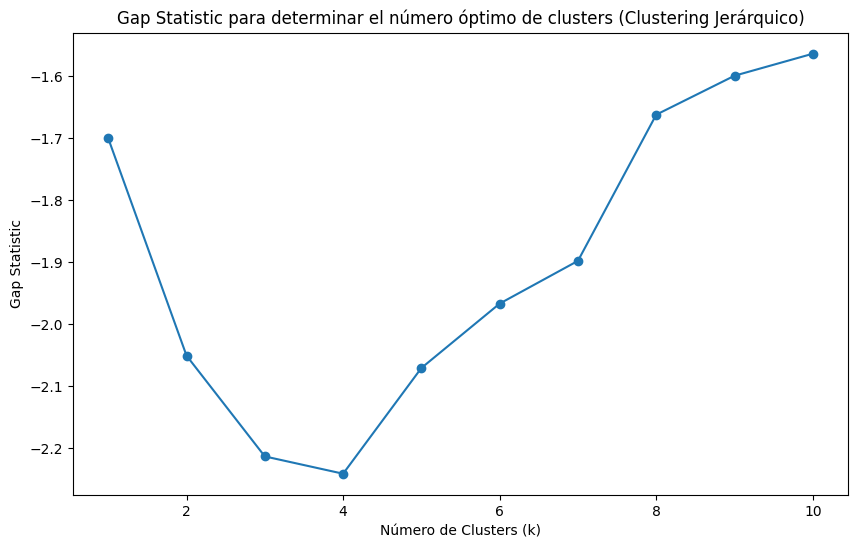

In [ ]:
print("Número óptimo de clusters según el Gap Statistic:", optimal_k)

plt.figure(figsize=(10, 6))
plt.plot(range(1, max_k + 1), gaps, marker='o')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Gap Statistic')
plt.title('Gap Statistic para determinar el número óptimo de clusters (Clustering Jerárquico)')
plt.show()

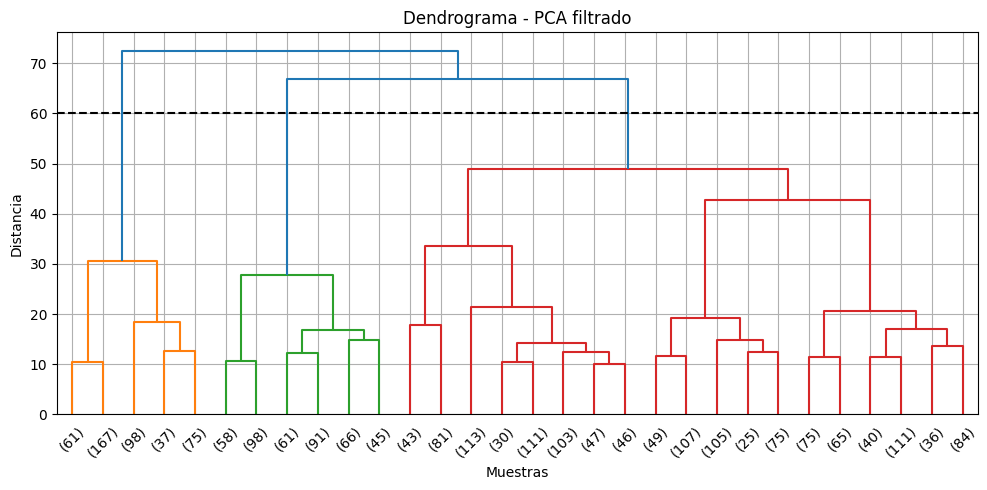

In [ ]:
# Calcular linkage
Z = linkage(X_sub, method='ward')

# Mostrar dendrograma
plt.figure(figsize=(10, 5))
dendrogram(Z, truncate_mode='lastp', p=30)
plt.title('Dendrograma - PCA filtrado')
plt.axhline(y=60, c='k', linestyle='dashed')
plt.xlabel('Muestras')
plt.ylabel('Distancia')
plt.grid(True)
plt.tight_layout()
plt.show()


En el dendograma, se observa un nivel de corte donde las ramas se separan de forma clara en 3. El método del Coeficiente de Silhouette respaldo ese número de clusters como el óptimo mientras que GAP dió como resultado 10. En consecuencia creemos que 3 es el número óptimo de clusters y procederomos a gráficarlos.

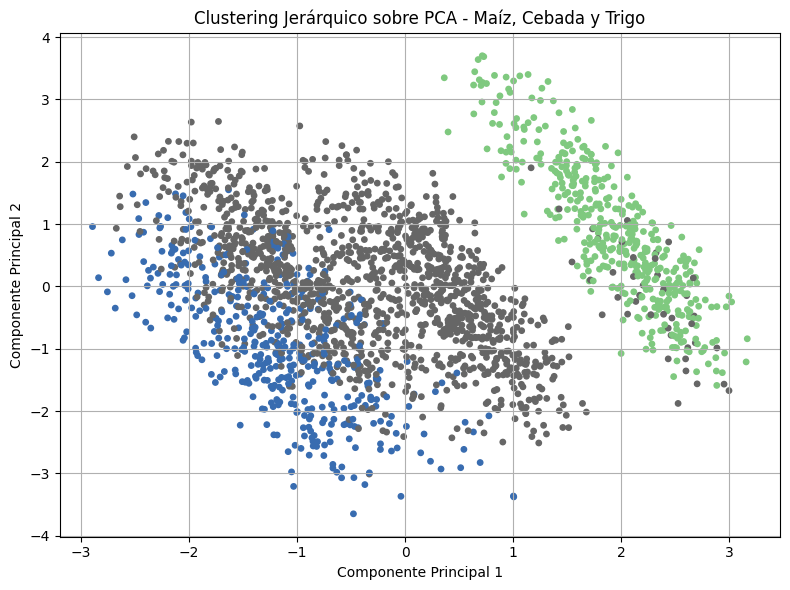

In [ ]:
# Obtener 3 clusters
clusters_hier = fcluster(Z, 3, criterion='maxclust')

# Graficar clusters jerárquicos
plt.figure(figsize=(8,6))
plt.scatter(X_sub_pca[:, 0], X_sub_pca[:, 1], c=clusters_hier, cmap='Accent', s=15)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Clustering Jerárquico sobre PCA - Maíz, Cebada y Trigo')
plt.grid(True)
plt.tight_layout()
plt.show()


Muestra una clara separación entre los grupos, lo que sugiere un buen agrupamiento de los datos.

# Conclusiones generales

A partir del análisis exploratorio, se concluyó que el dataset no presentaba valores faltantes y que los valores atípicos detectados (principalmente en potasio) no debían eliminarse para preservar información relevante. La reducción de dimensionalidad mediante PCA reveló que cuatro componentes principales fueron suficientes para explicar más del 90% de la varianza, indicando que la mayoría de la información se concentra en pocas componentes. Pca, Isomap y t-SNE confirmaron que los datos presentan estructuras de grupo.

En cuanto al análisis de clustering, con K-means el coeficiente de Silhouette señaló que la partición óptima es de 3 mientras que con el método del codo se pudo visualizar en 4. GAP sugirió 10. Con Clustering Jerárquico el coeficiente de Silhouette dió 3 y GAP 10. Sin embargo en el dendograma se pudo visualizar un agrupamiento marcado en 3 principalmente.
Con Clustering jerárquico se visualizó un mejor agrupamiento y estructura de los datos.
En resumen, el dataset muestra cierta estructura de agrupamientos, adecuada para su segmentación en tres clusters principales. Estos resultados proporcionan una base sólida para futuros modelos predictivos o análisis más detallados por grupo.